# Hurst-Based Basket Trading Model

A systematic momentum strategy that selects assets based on their
**rolling Hurst exponent** — allocating to the most persistent (trending)
assets and using bonds as a risk-off hedge.

## Strategy Overview

| Parameter | Value |
|-----------|-------|
| **Universe** | 9 risk-on assets + 1 risk-off (TLT) |
| **Timeframe** | Daily (1D) |
| **Ranking** | Rolling Hurst exponent (R/S, 63-day window) |
| **Selection** | Top 3 assets by persistence (H > 0.5) |
| **Risk-Off** | TLT (20Y Treasury ETF) — absorbs unused weight |
| **Rebalancing** | Biweekly (every 10 trading days) |
| **Allocation** | Equal-weight among selected; remainder → TLT |
| **Lookahead** | 1-day signal shift — signal on day t, trade on day t+1 |

## Strategy Logic

1. Compute a **rolling Hurst exponent** for each of the 9 risk-on assets
2. **Shift signals by 1 day** to prevent lookahead bias
3. Every 10 trading days, **rank** all assets by their lagged Hurst
4. Select **top 3** with H > 0.5 (persistent / trending)
5. **Equal-weight** the selected assets (33.3% each)
6. If fewer than 3 qualify, allocate remaining weight to **TLT** (risk-off)
7. If none qualify, go **100% TLT**

## Lookahead Bias Prevention

The signal is shifted by 1 day so Hurst computed from returns up to day t
is only used for trading on day t+1.

- Day t-63 to t-1 → returns used to compute Hurst[t]
- Day t → Hurst[t] known at close
- Day t+1 → signal shifted, weights applied to return[t+1]

The 1-day shift ensures we **never trade on the same bar** that generated the signal.

## Asset Universe

| # | Ticker | Asset | Role |
|---|--------|-------|------|
| 1 | BTC-USD | Bitcoin | Risk-on |
| 2 | QQQ | Nasdaq 100 ETF | Risk-on |
| 3 | SPY | S&P 500 ETF | Risk-on |
| 4 | AAPL | Apple | Risk-on |
| 5 | TSLA | Tesla | Risk-on |
| 6 | GLD | Gold ETF | Risk-on |
| 7 | NVDA | NVIDIA | Risk-on |
| 8 | AMZN | Amazon | Risk-on |
| 9 | XLE | Energy Sector ETF | Risk-on |
| 10 | **TLT** | **20Y Treasury ETF** | **Risk-off** |

In [1]:
# ==============================================================
#  IMPORTS & CONFIGURATION
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (16, 7),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.facecolor': 'white',
})

# --- STRATEGY PARAMETERS ---
ALL_TICKERS  = ['BTC-USD', 'QQQ', 'SPY', 'AAPL', 'TSLA',
                'GLD', 'NVDA', 'AMZN', 'XLE', 'TLT']
RISK_OFF     = 'TLT'
RISK_ON      = [t for t in ALL_TICKERS if t != RISK_OFF]

START_DATE   = '2018-01-01'
END_DATE     = '2025-01-01'
HURST_WINDOW = 63     # ~3 months
REBAL_PERIOD = 10     # biweekly
TOP_N        = 3      # assets to hold
MIN_HURST    = 0.5    # persistence threshold
SIGNAL_LAG   = 1      # 1-day shift to prevent lookahead
INITIAL_CAP  = 100_000

print(f'Risk-on  : {len(RISK_ON)} assets — {RISK_ON}')
print(f'Risk-off : {RISK_OFF}')
print(f'Period   : {START_DATE} to {END_DATE}')
print(f'Hurst win: {HURST_WINDOW}d | Rebalance: every {REBAL_PERIOD}d')
print(f'Signal lag: {SIGNAL_LAG}d (lookahead protection)')
print(f'Selection : top {TOP_N} with H > {MIN_HURST}, remainder -> {RISK_OFF}')

Risk-on  : 9 assets — ['BTC-USD', 'QQQ', 'SPY', 'AAPL', 'TSLA', 'GLD', 'NVDA', 'AMZN', 'XLE']
Risk-off : TLT
Period   : 2018-01-01 to 2025-01-01
Hurst win: 63d | Rebalance: every 10d
Signal lag: 1d (lookahead protection)
Selection : top 3 with H > 0.5, remainder -> TLT


In [2]:
# ==============================================================
#  DOWNLOAD DAILY CLOSE PRICES
# ==============================================================

close_prices = pd.DataFrame()

for ticker in ALL_TICKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE,
                     progress=False, auto_adjust=True)
    if len(df) > 0:
        close_prices[ticker] = df['Close'].squeeze()

# Forward-fill missing values, drop remaining NaNs
close_prices = close_prices.ffill().dropna()
returns = close_prices.pct_change().dropna()

print(f'Date range   : {close_prices.index[0].date()} to {close_prices.index[-1].date()}')
print(f'Trading days : {len(close_prices)}\n')

for t in close_prices.columns:
    role = 'RISK-OFF' if t == RISK_OFF else 'risk-on'
    pct  = (close_prices[t].iloc[-1] / close_prices[t].iloc[0] - 1) * 100
    print(f'  {t:>8} [{role:>8}] | '
          f'{close_prices[t].iloc[0]:>10,.2f} -> '
          f'{close_prices[t].iloc[-1]:>10,.2f} | '
          f'{pct:>+8.1f}%')

Date range   : 2018-01-02 to 2024-12-31
Trading days : 2556

   BTC-USD [ risk-on] |  14,982.10 ->  93,429.20 |   +523.6%
       QQQ [ risk-on] |     150.22 ->     508.01 |   +238.2%
       SPY [ risk-on] |     236.56 ->     577.70 |   +144.2%
      AAPL [ risk-on] |      40.30 ->     249.06 |   +517.9%
      TSLA [ risk-on] |      21.37 ->     403.84 |  +1789.9%
       GLD [ risk-on] |     125.15 ->     242.13 |    +93.5%
      NVDA [ risk-on] |       4.93 ->     134.25 |  +2624.0%
      AMZN [ risk-on] |      59.45 ->     219.39 |   +269.0%
       XLE [ risk-on] |      25.75 ->      41.18 |    +59.9%
       TLT [RISK-OFF] |      99.46 ->      82.68 |    -16.9%


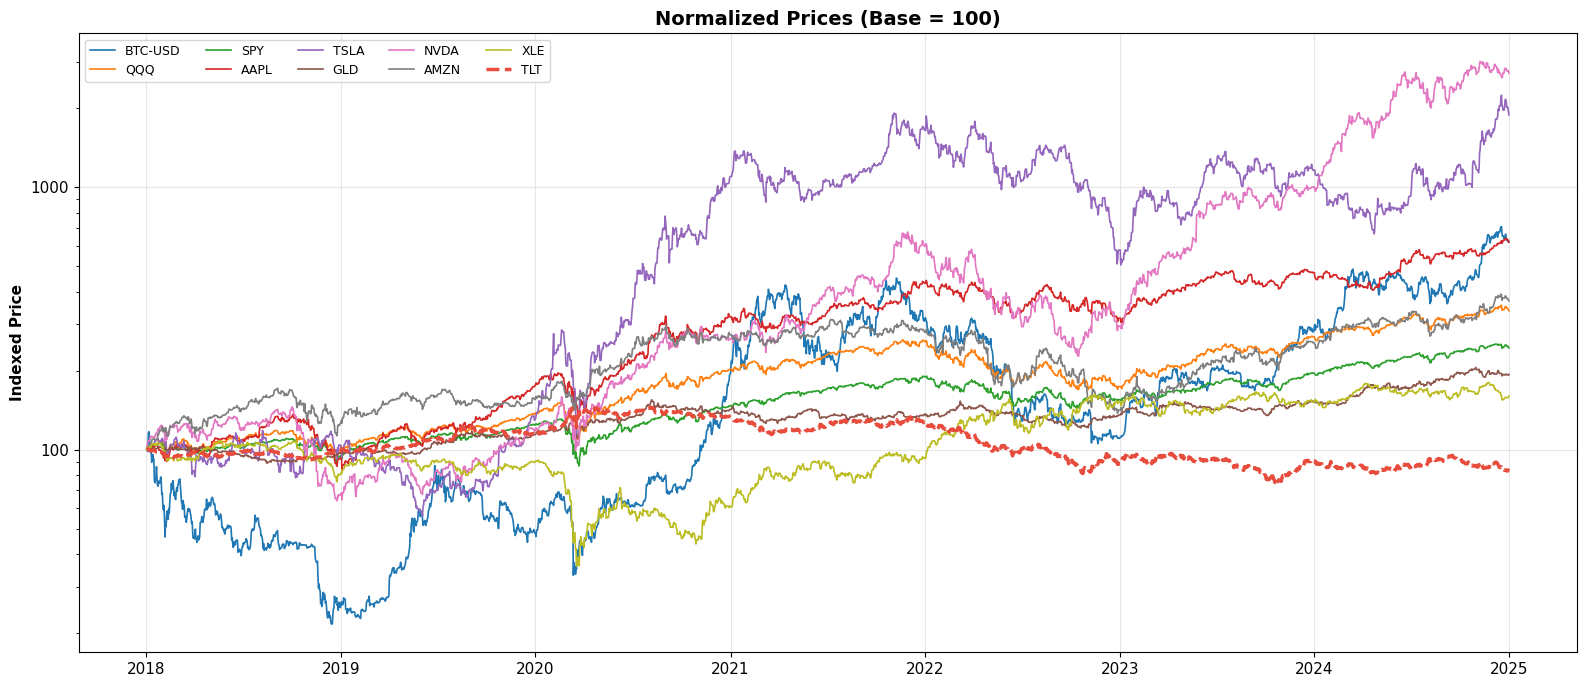

In [3]:
# ==============================================================
#  NORMALIZED PRICE CHART (BASE = 100)
# ==============================================================

norm = close_prices / close_prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(16, 7))

for col in norm.columns:
    style = ({'linewidth': 2.5, 'linestyle': '--', 'color': '#e74c3c'}
             if col == RISK_OFF
             else {'linewidth': 1.2})
    ax.plot(norm.index, norm[col], label=col, **style)

ax.set_title('Normalized Prices (Base = 100)', fontsize=14)
ax.set_ylabel('Indexed Price')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0f}')
)
ax.legend(ncol=5, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Rolling Hurst Exponent

Computed for **risk-on assets only** (9 assets). TLT is excluded from ranking.

After computing, we **shift the signal by 1 day** so that Hurst computed
from returns up to day t is only used for trading on day t+1.

In [4]:
# ==============================================================
#  HURST EXPONENT — R/S METHOD (VECTORIZED)
# ==============================================================

def compute_rs(series):
    """R/S statistic for a single window."""
    mean    = np.mean(series)
    cum_dev = np.cumsum(series - mean)
    R       = np.max(cum_dev) - np.min(cum_dev)
    S       = np.std(series, ddof=0)
    return R / S if S > 0 else np.nan


def hurst_rs(series, min_win=8, max_win=None, n_pts=15):
    """
    Estimate Hurst exponent via R/S log-log regression.
    Returns NaN if series is too short or fit is unreliable.
    """
    N = len(series)
    if max_win is None:
        max_win = N // 2
    if max_win <= min_win or N < 20:
        return np.nan

    sizes = np.unique(
        np.logspace(np.log10(min_win), np.log10(max_win), n_pts).astype(int)
    )

    ln, lr = [], []
    for n in sizes:
        ns = N // n
        if ns < 1:
            continue
        # R/S for each non-overlapping sub-window
        v = [compute_rs(series[i*n:(i+1)*n]) for i in range(ns)]
        v = [x for x in v if not np.isnan(x)]
        if v:
            ln.append(np.log(n))
            lr.append(np.log(np.mean(v)))

    if len(ln) < 3:
        return np.nan

    return np.polyfit(ln, lr, 1)[0]


def compute_rolling_hurst_fast(returns_df, window):
    """
    Rolling Hurst for all columns using numpy arrays.
    Returns DataFrame with NaN for the warmup period.
    """
    result = {}
    for col in returns_df.columns:
        vals  = returns_df[col].values
        h_arr = np.full(len(vals), np.nan)
        for i in range(window, len(vals)):
            # Use returns[i-window : i] — no lookahead
            h_arr[i] = hurst_rs(vals[i - window : i])
        result[col] = h_arr

    return pd.DataFrame(result, index=returns_df.index)


print('Hurst functions defined.')

Hurst functions defined.


In [5]:
# ==============================================================
#  COMPUTE ROLLING HURST + APPLY SIGNAL LAG
# ==============================================================

risk_on_returns = returns[RISK_ON]

print(f'Computing rolling Hurst (window={HURST_WINDOW}) '
      f'for {len(RISK_ON)} risk-on assets...')

hurst_raw = compute_rolling_hurst_fast(risk_on_returns, HURST_WINDOW)

# CRITICAL: shift by SIGNAL_LAG to prevent lookahead
# Hurst[t] uses returns[t-63 : t-1], known at close of t-1
# Shifting by 1 means we only act on it from day t+1 onward
hurst_df = hurst_raw.shift(SIGNAL_LAG)
hurst_df = hurst_df.dropna(how='all')

print(f'Done: {len(hurst_df)} obs x {len(hurst_df.columns)} assets')
print(f'Signal lag : {SIGNAL_LAG} day(s) applied')
print(f'\nLatest Hurst (ranked, after lag):')
print(hurst_df.iloc[-1].sort_values(ascending=False).to_string())

Computing rolling Hurst (window=63) for 9 risk-on assets...
Done: 2491 obs x 9 assets
Signal lag : 1 day(s) applied

Latest Hurst (ranked, after lag):
TSLA       0.779345
NVDA       0.666074
XLE        0.655288
GLD        0.625452
SPY        0.607723
AMZN       0.593945
BTC-USD    0.590843
QQQ        0.505332
AAPL       0.489111


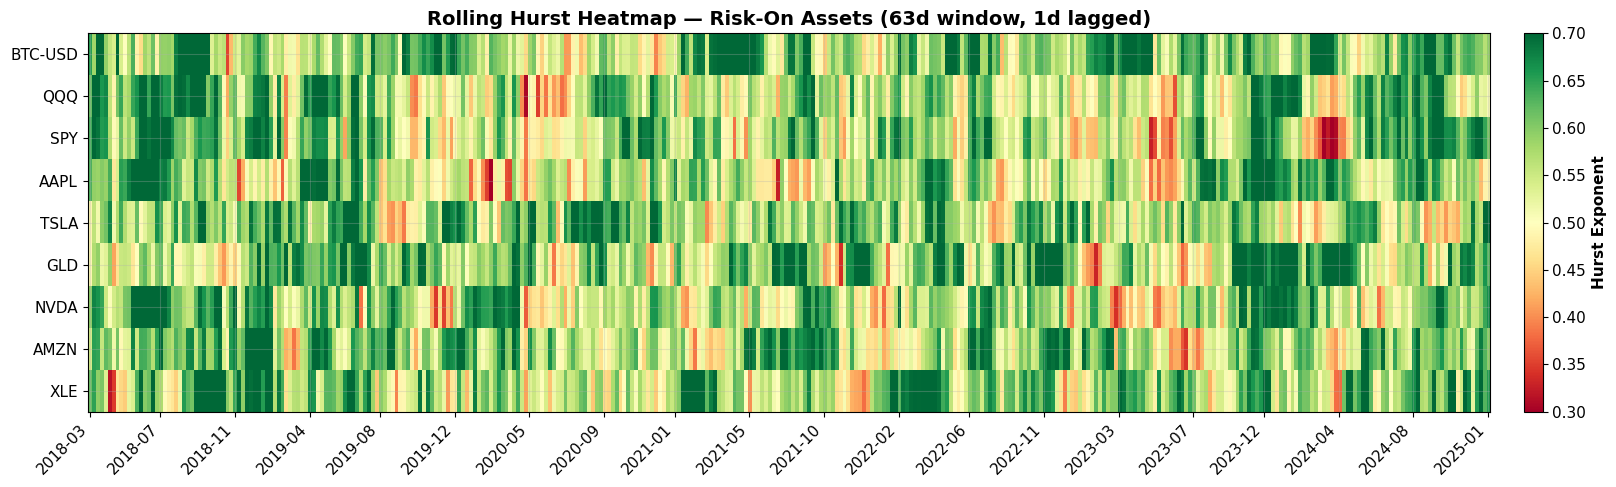

In [6]:
# ==============================================================
#  ROLLING HURST HEATMAP
# ==============================================================

hw = hurst_df.resample('W').last().dropna(how='all')

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(hw.T.values, aspect='auto', cmap='RdYlGn',
               vmin=0.3, vmax=0.7, interpolation='nearest')

ax.set_yticks(range(len(hw.columns)))
ax.set_yticklabels(hw.columns)

ti = np.linspace(0, len(hw) - 1, 20, dtype=int)
ax.set_xticks(ti)
ax.set_xticklabels(
    [hw.index[i].strftime('%Y-%m') for i in ti],
    rotation=45, ha='right'
)

plt.colorbar(im, ax=ax, pad=0.02).set_label('Hurst Exponent')
ax.set_title('Rolling Hurst Heatmap — Risk-On Assets '
             f'({HURST_WINDOW}d window, {SIGNAL_LAG}d lagged)', fontsize=14)
plt.tight_layout()
plt.show()

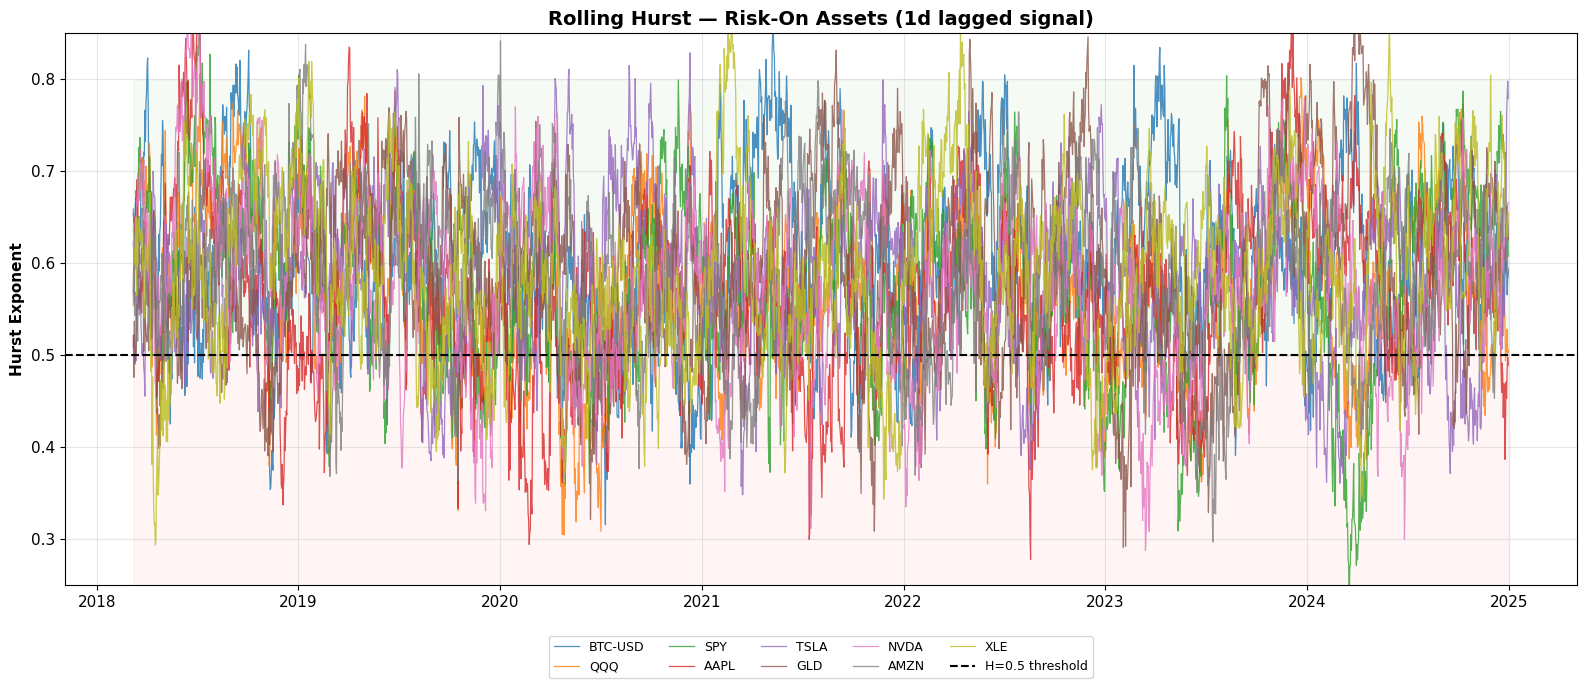

In [8]:
# ==============================================================
#  ROLLING HURST LINE CHART
# ==============================================================

fig, ax = plt.subplots(figsize=(16, 7))

for col in hurst_df.columns:
    ax.plot(hurst_df.index, hurst_df[col], lw=0.9, alpha=0.8, label=col)

ax.axhline(MIN_HURST, color='black', lw=1.5, ls='--',
           label=f'H={MIN_HURST} threshold')
ax.fill_between(hurst_df.index, MIN_HURST, 0.8,
                alpha=0.04, color='green')
ax.fill_between(hurst_df.index, 0.25, MIN_HURST,
                alpha=0.04, color='red')
ax.set_ylim(0.25, 0.85)
ax.set_ylabel('Hurst Exponent')
ax.set_title(f'Rolling Hurst — Risk-On Assets ({SIGNAL_LAG}d lagged signal)',
             fontsize=14)
ax.legend(ncol=5, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Backtest Engine

**No data leakage**: Hurst signals are already shifted by 1 day.
On any given day, the backtest only sees yesterday's Hurst.

### Allocation Logic

| Scenario | Risk-On Weight | TLT Weight |
|----------|---------------|------------|
| 3 assets qualify | 100% (33.3% × 3) | 0% |
| 2 assets qualify | 66.7% (33.3% × 2) | 33.3% |
| 1 asset qualifies | 33.3% | 66.7% |
| 0 assets qualify | 0% | **100%** |

In [9]:
# ==============================================================
#  BACKTEST ENGINE (WITH TLT RISK-OFF, NO LOOKAHEAD)
# ==============================================================

def run_backtest(returns_df, hurst_df, risk_off_ticker,
                 top_n, rebal_period, min_hurst):
    """
    Hurst basket backtest with risk-off asset.
    hurst_df is ALREADY lagged — no additional shift needed.
    Weights set on rebalance day are applied starting that day.
    """
    # Align indices
    common_idx = returns_df.index.intersection(hurst_df.index)
    ret = returns_df.loc[common_idx]
    hst = hurst_df.loc[common_idx]

    all_assets = list(ret.columns)
    n_days     = len(ret)

    # Pre-allocate arrays for speed
    port_ret_arr = np.zeros(n_days)
    weight_arr   = np.zeros((n_days, len(all_assets)))
    asset_idx    = {a: i for i, a in enumerate(all_assets)}
    rebal_log    = []

    # Start fully in risk-off
    cur_w = np.zeros(len(all_assets))
    cur_w[asset_idx[risk_off_ticker]] = 1.0
    days_since = rebal_period  # force rebalance on day 1

    ret_vals = ret.values  # numpy for speed

    for i in range(n_days):
        days_since += 1
        date = ret.index[i]

        if days_since >= rebal_period:
            h_vals = hst.iloc[i].dropna()

            # Rank risk-on assets by lagged Hurst
            persistent = h_vals[h_vals > min_hurst].sort_values(ascending=False)
            selected   = persistent.head(top_n)
            n_sel      = len(selected)

            # Reset and set equal weights
            cur_w[:] = 0.0
            unit_w   = 1.0 / top_n

            for ticker in selected.index:
                cur_w[asset_idx[ticker]] = unit_w

            # Remaining weight → TLT
            risk_off_w = 1.0 - n_sel * unit_w
            cur_w[asset_idx[risk_off_ticker]] = risk_off_w

            rebal_log.append({
                'date':         date,
                'selected':     list(selected.index),
                'hurst_values': selected.to_dict(),
                'n_selected':   n_sel,
                'tlt_weight':   risk_off_w,
            })
            days_since = 0

        # Daily portfolio return = dot product of weights and returns
        port_ret_arr[i] = np.dot(cur_w, ret_vals[i])
        weight_arr[i]   = cur_w.copy()

    port_ret = pd.Series(port_ret_arr, index=ret.index)
    weights  = pd.DataFrame(weight_arr, index=ret.index, columns=all_assets)

    return port_ret, weights, rebal_log


print('Backtest engine defined.')

Backtest engine defined.


In [10]:
# ==============================================================
#  RUN BACKTEST
# ==============================================================

port_ret, holdings, rebal_log = run_backtest(
    returns, hurst_df, RISK_OFF, TOP_N, REBAL_PERIOD, MIN_HURST
)

equity     = (1 + port_ret).cumprod() * INITIAL_CAP
spy_ret    = returns['SPY'].reindex(port_ret.index).fillna(0)
spy_equity = (1 + spy_ret).cumprod() * INITIAL_CAP

# Risk-off allocation stats
tlt_weights     = [r['tlt_weight'] for r in rebal_log]
pct_full_riskon  = sum(1 for w in tlt_weights if w == 0)    / len(tlt_weights) * 100
pct_full_riskoff = sum(1 for w in tlt_weights if w >= 1.0)  / len(tlt_weights) * 100

print(f'Backtest complete: {len(rebal_log)} rebalances')
print(f'\nFinal equity : ${equity.iloc[-1]:>10,.0f}  |  '
      f'SPY B&H: ${spy_equity.iloc[-1]:>10,.0f}')
print(f'\nRisk-off stats:')
print(f'  Avg TLT weight  : {np.mean(tlt_weights):.1%}')
print(f'  Fully risk-on   : {pct_full_riskon:.1f}% of rebalances')
print(f'  Fully risk-off  : {pct_full_riskoff:.1f}% of rebalances (100% TLT)')

Backtest complete: 250 rebalances

Final equity : $   949,592  |  SPY B&H: $   240,616

Risk-off stats:
  Avg TLT weight  : 0.3%
  Fully risk-on   : 99.2% of rebalances
  Fully risk-off  : 0.0% of rebalances (100% TLT)


---
## 4. Performance — Hurst Strategy vs SPY Buy & Hold

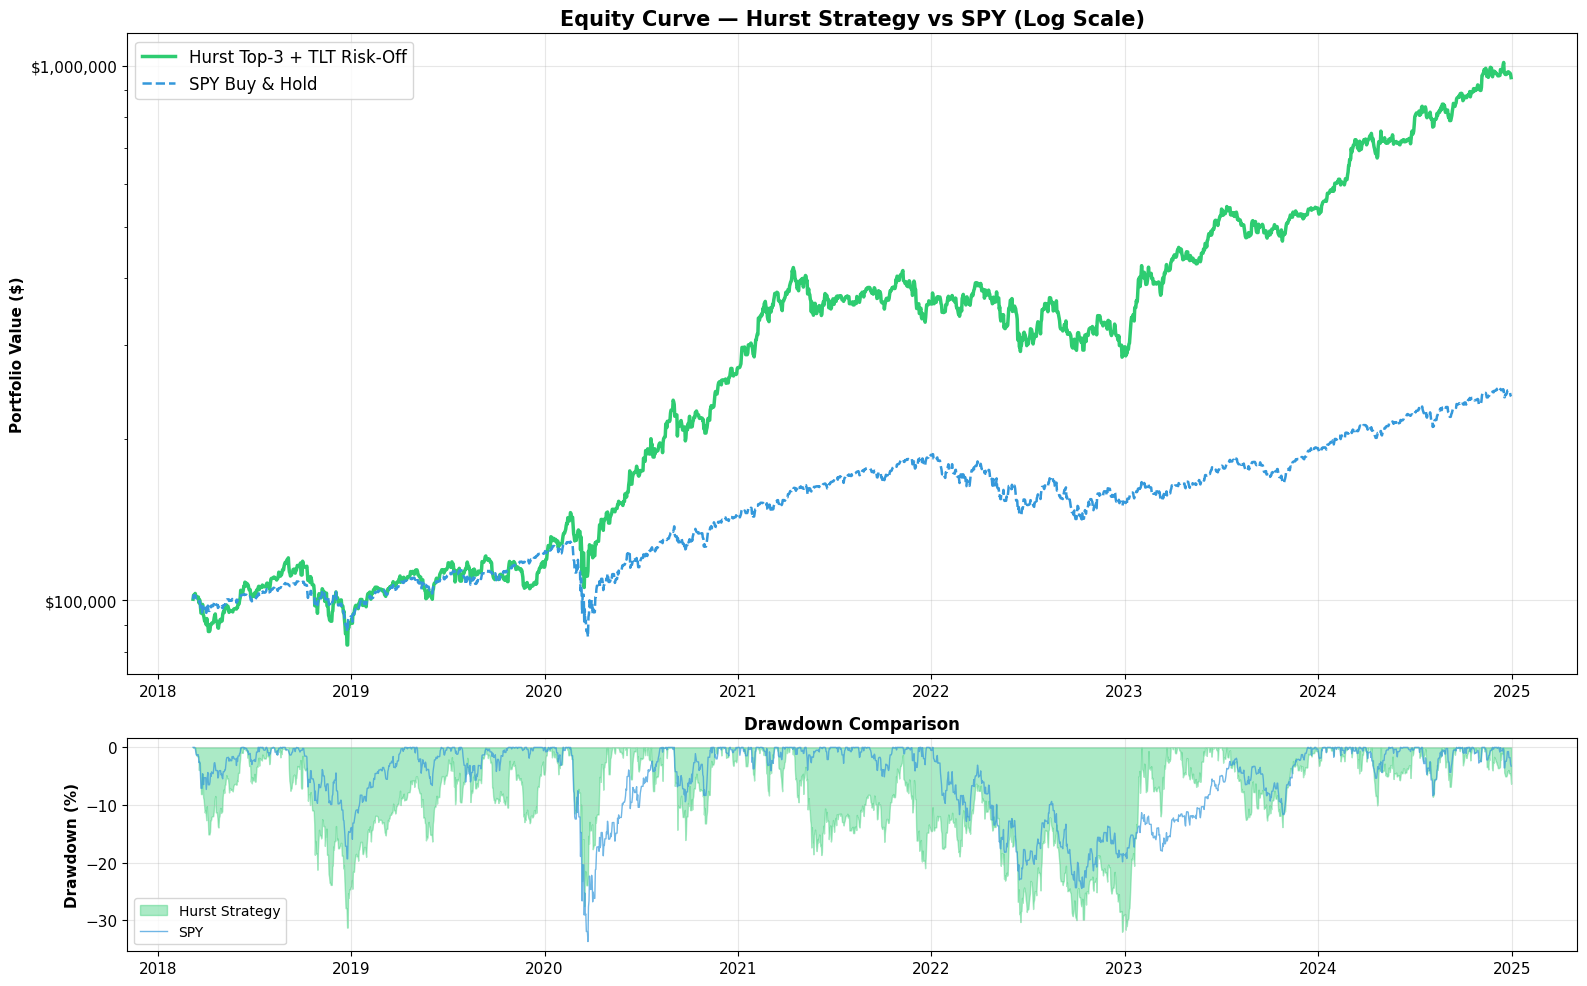

In [11]:
# ==============================================================
#  EQUITY CURVE (LOG SCALE) + DRAWDOWN
# ==============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10),
                                gridspec_kw={'height_ratios': [3, 1]})

# Equity curve
ax1.plot(equity.index, equity,
         color='#2ecc71', lw=2.5,
         label=f'Hurst Top-{TOP_N} + TLT Risk-Off')
ax1.plot(spy_equity.index, spy_equity,
         color='#3498db', lw=1.8, linestyle='--',
         label='SPY Buy & Hold')

# Shade periods with heavy risk-off allocation
for r in rebal_log:
    if r['tlt_weight'] > 0.5:
        ax1.axvline(r['date'], color='#e74c3c', alpha=0.05, lw=3)

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:,.0f}')
)
ax1.set_title('Equity Curve — Hurst Strategy vs SPY (Log Scale)', fontsize=15)
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend(fontsize=12)

# Drawdown
dd_strat = (equity     / equity.cummax()     - 1) * 100
dd_spy   = (spy_equity / spy_equity.cummax() - 1) * 100

ax2.fill_between(dd_strat.index, dd_strat, 0,
                 color='#2ecc71', alpha=0.4, label='Hurst Strategy')
ax2.plot(dd_spy.index, dd_spy,
         color='#3498db', lw=1, alpha=0.7, label='SPY')
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown Comparison', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
# ==============================================================
#  PERFORMANCE METRICS TABLE
# ==============================================================

def calc_metrics(ret_s, name, rf=0.04):
    """Comprehensive performance metrics."""
    r   = ret_s.dropna()
    n   = len(r)
    eq  = (1 + r).cumprod()
    yrs = n / 252

    tot    = eq.iloc[-1] - 1
    cagr   = (1 + tot) ** (1 / yrs) - 1
    vol    = r.std() * np.sqrt(252)
    rfd    = (1 + rf) ** (1/252) - 1
    sharpe = (r.mean() - rfd) / r.std() * np.sqrt(252) if r.std() > 0 else 0
    ds     = r[r < 0].std() * np.sqrt(252)
    sortino = (cagr - rf) / ds if ds > 0 else 0
    dd     = eq / eq.cummax() - 1
    mdd    = dd.min()
    calmar = cagr / abs(mdd) if abs(mdd) > 0 else 0
    wr     = (r > 0).mean()
    g      = r[r > 0].sum()
    l      = abs(r[r < 0].sum())
    pf     = g / l if l > 0 else float('inf')

    return {
        'Strategy':      name,
        'CAGR':          f'{cagr:.1%}',
        'Vol':           f'{vol:.1%}',
        'Sharpe':        f'{sharpe:.2f}',
        'Sortino':       f'{sortino:.2f}',
        'Max DD':        f'{mdd:.1%}',
        'Calmar':        f'{calmar:.2f}',
        'Win Rate':      f'{wr:.1%}',
        'Profit Factor': f'{pf:.2f}',
        'Total Return':  f'{tot:.1%}',
    }


metrics = pd.DataFrame([
    calc_metrics(port_ret, f'Hurst Top-{TOP_N} + TLT'),
    calc_metrics(spy_ret,  'SPY Buy & Hold'),
]).set_index('Strategy')

print('\n' + '=' * 85)
print('PERFORMANCE COMPARISON')
print('=' * 85)
print(metrics.to_string())


PERFORMANCE COMPARISON
                    CAGR    Vol Sharpe Sortino  Max DD Calmar Win Rate Profit Factor Total Return
Strategy                                                                                         
Hurst Top-3 + TLT  25.6%  25.1%   0.88    1.03  -32.0%   0.80    45.4%          1.23       849.6%
SPY Buy & Hold      9.3%  16.2%   0.39    0.33  -33.7%   0.28    37.9%          1.16       140.6%


---
## 5. Holdings & Allocation Analysis

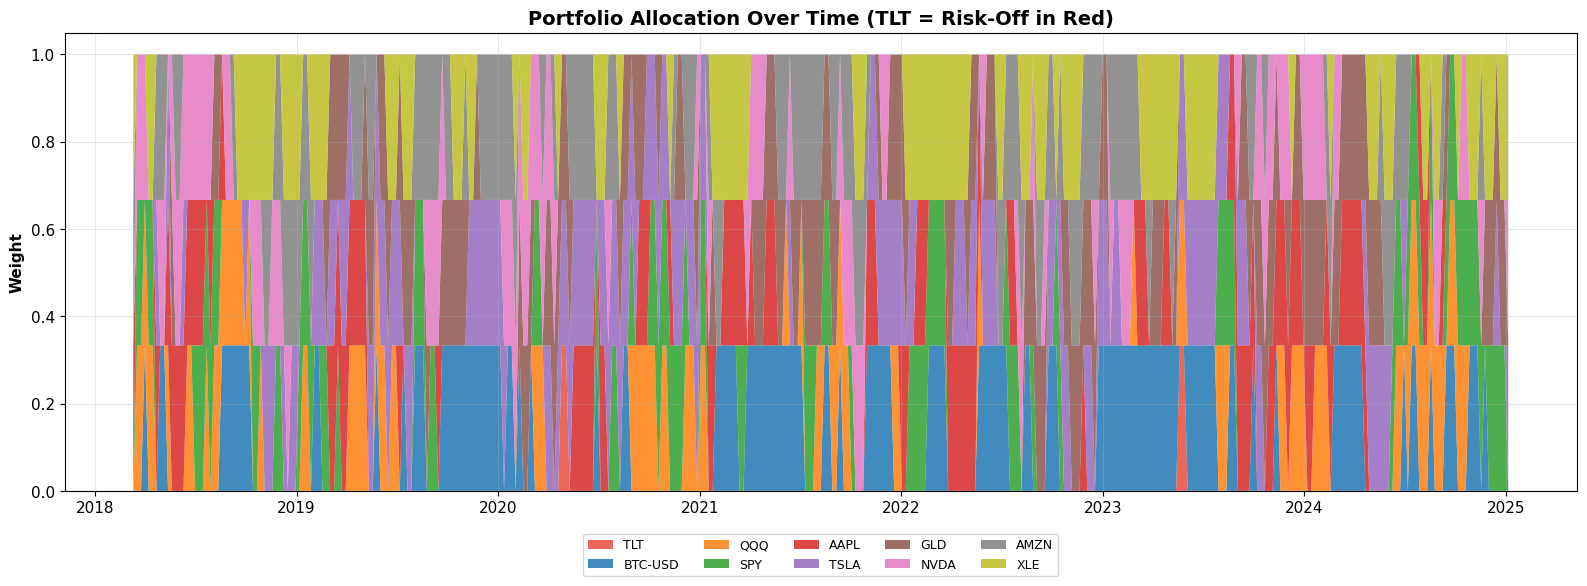

In [13]:
# ==============================================================
#  HOLDINGS STACKED AREA (TLT HIGHLIGHTED)
# ==============================================================

wk   = holdings.resample('W').last().dropna(how='all').fillna(0)
cols = [RISK_OFF] + [c for c in wk.columns if c != RISK_OFF]
wk   = wk[cols]

fig, ax = plt.subplots(figsize=(16, 6))
colors  = ['#e74c3c'] + [plt.cm.tab10(i) for i in range(len(cols) - 1)]

ax.stackplot(wk.index, [wk[c] for c in wk.columns],
             labels=wk.columns, colors=colors, alpha=0.85)
ax.set_title('Portfolio Allocation Over Time (TLT = Risk-Off in Red)',
             fontsize=14)
ax.set_ylabel('Weight')
ax.set_ylim(0, 1.05)
ax.legend(ncol=5, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), fontsize=9)
plt.tight_layout()
plt.show()

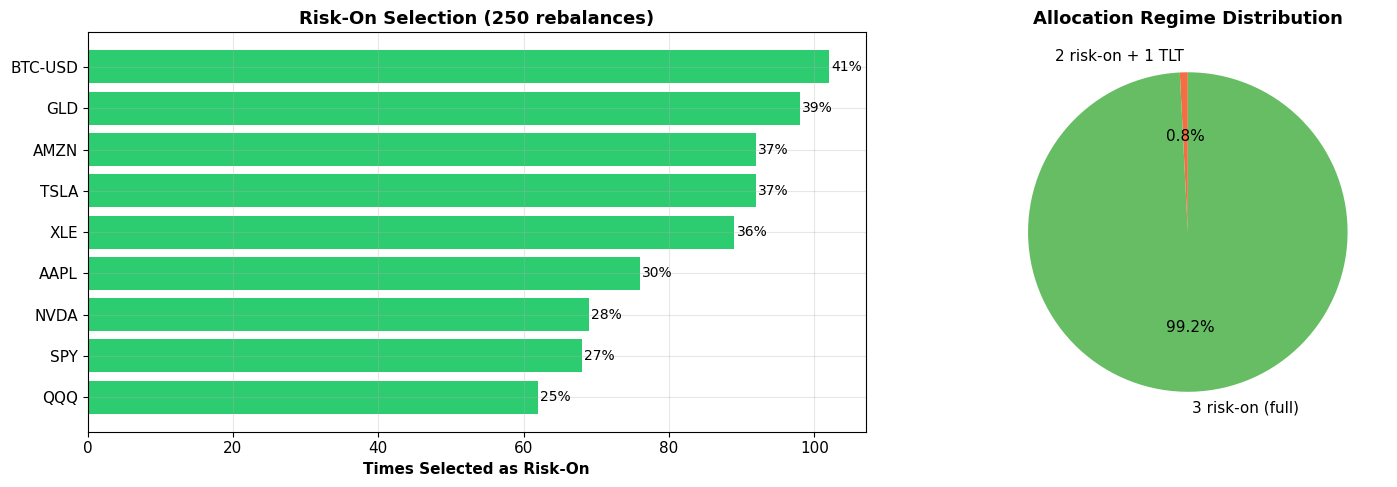

TLT held (any weight) in 2/250 rebalances (1%)


In [14]:
# ==============================================================
#  SELECTION FREQUENCY + RISK-OFF ALLOCATION
# ==============================================================

all_sel = [t for r in rebal_log for t in r['selected']]
freq    = Counter(all_sel)
total   = len(rebal_log)

tickers_sorted = [t for t, _ in freq.most_common()]
counts_sorted  = [c for _, c in freq.most_common()]

n_counts = Counter(r['n_selected'] for r in rebal_log)
labels   = [f'{n} risk-on + {TOP_N-n} TLT' if n < TOP_N
            else f'{n} risk-on (full)'
            for n in sorted(n_counts.keys())]
sizes    = [n_counts[n] for n in sorted(n_counts.keys())]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Selection frequency bar chart
ax1.barh(tickers_sorted, counts_sorted, color='#2ecc71')
ax1.set_xlabel('Times Selected as Risk-On')
ax1.set_title(f'Risk-On Selection ({total} rebalances)', fontsize=13)
ax1.invert_yaxis()
for i, (t, c) in enumerate(zip(tickers_sorted, counts_sorted)):
    ax1.text(c + 0.3, i, f'{c/total:.0%}', va='center', fontsize=10)

# Allocation regime pie
ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sizes))))
ax2.set_title('Allocation Regime Distribution', fontsize=13)

plt.tight_layout()
plt.show()

tlt_times = sum(1 for r in rebal_log if r['tlt_weight'] > 0)
print(f'TLT held (any weight) in {tlt_times}/{total} '
      f'rebalances ({tlt_times/total:.0%})')

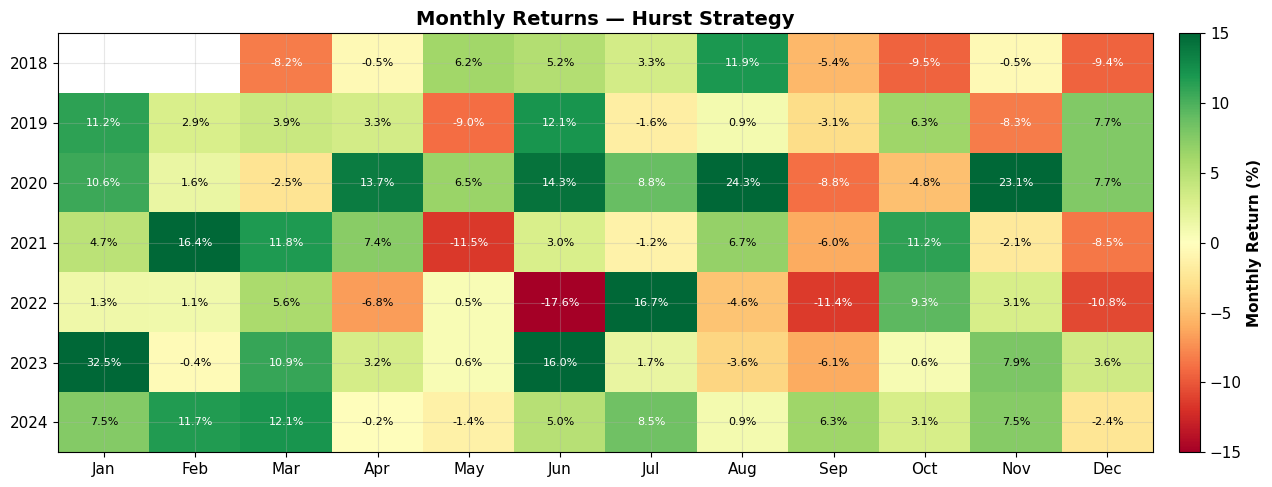

In [15]:
# ==============================================================
#  MONTHLY RETURNS HEATMAP
# ==============================================================

mo  = port_ret.resample('ME').apply(lambda x: (1+x).prod()-1)
mdf = pd.DataFrame({
    'Year':   mo.index.year,
    'Month':  mo.index.month,
    'Return': mo.values
})
pv = mdf.pivot_table(values='Return', index='Year', columns='Month')
pv.columns = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pv.columns)]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pv.values * 100, cmap='RdYlGn',
               aspect='auto', vmin=-15, vmax=15)

ax.set_xticks(range(len(pv.columns)))
ax.set_xticklabels(pv.columns)
ax.set_yticks(range(len(pv.index)))
ax.set_yticklabels(pv.index)

for i in range(len(pv.index)):
    for j in range(len(pv.columns)):
        v = pv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v*100:.1f}%', ha='center', va='center',
                    fontsize=8,
                    color='black' if abs(v) < 0.08 else 'white')

plt.colorbar(im, ax=ax, pad=0.02).set_label('Monthly Return (%)')
ax.set_title('Monthly Returns — Hurst Strategy', fontsize=14)
plt.tight_layout()
plt.show()

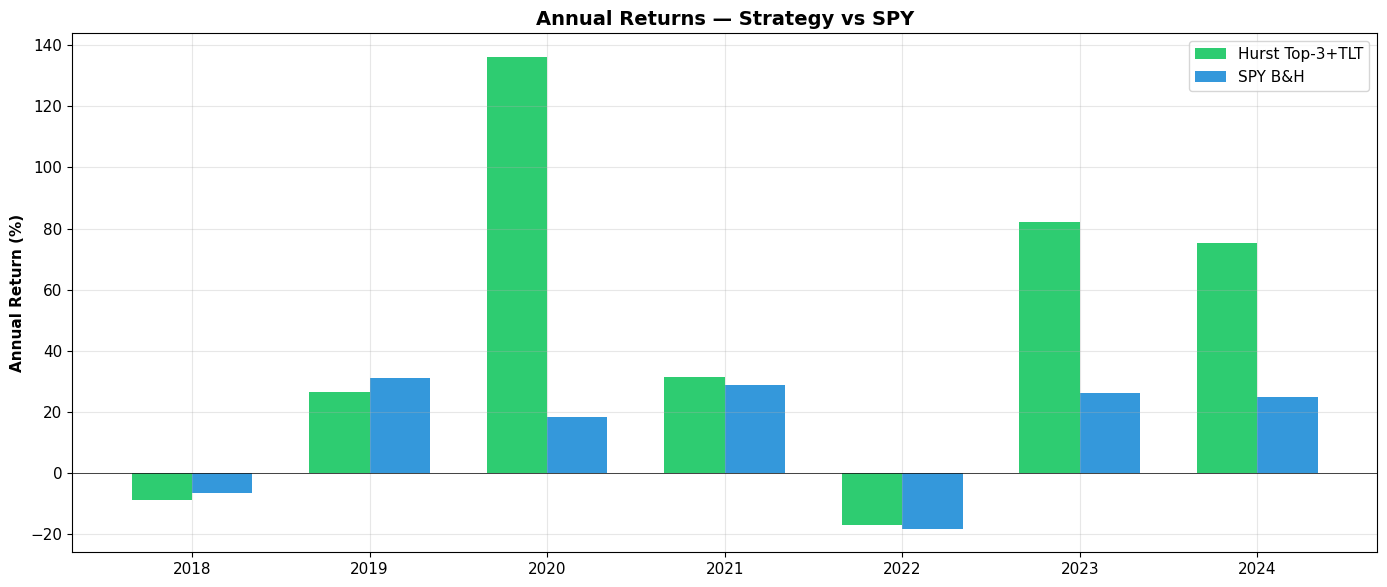

In [16]:
# ==============================================================
#  ANNUAL RETURNS COMPARISON
# ==============================================================

ann_s   = port_ret.resample('YE').apply(lambda x: (1+x).prod()-1)
ann_spy = spy_ret.resample('YE').apply(lambda x: (1+x).prod()-1)
yrs     = ann_s.index.year
x       = np.arange(len(yrs))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 0.17, ann_s.values   * 100, 0.34,
       label=f'Hurst Top-{TOP_N}+TLT', color='#2ecc71')
ax.bar(x + 0.17, ann_spy.values * 100, 0.34,
       label='SPY B&H',                color='#3498db')

ax.set_xticks(x)
ax.set_xticklabels(yrs)
ax.set_ylabel('Annual Return (%)')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Annual Returns — Strategy vs SPY', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

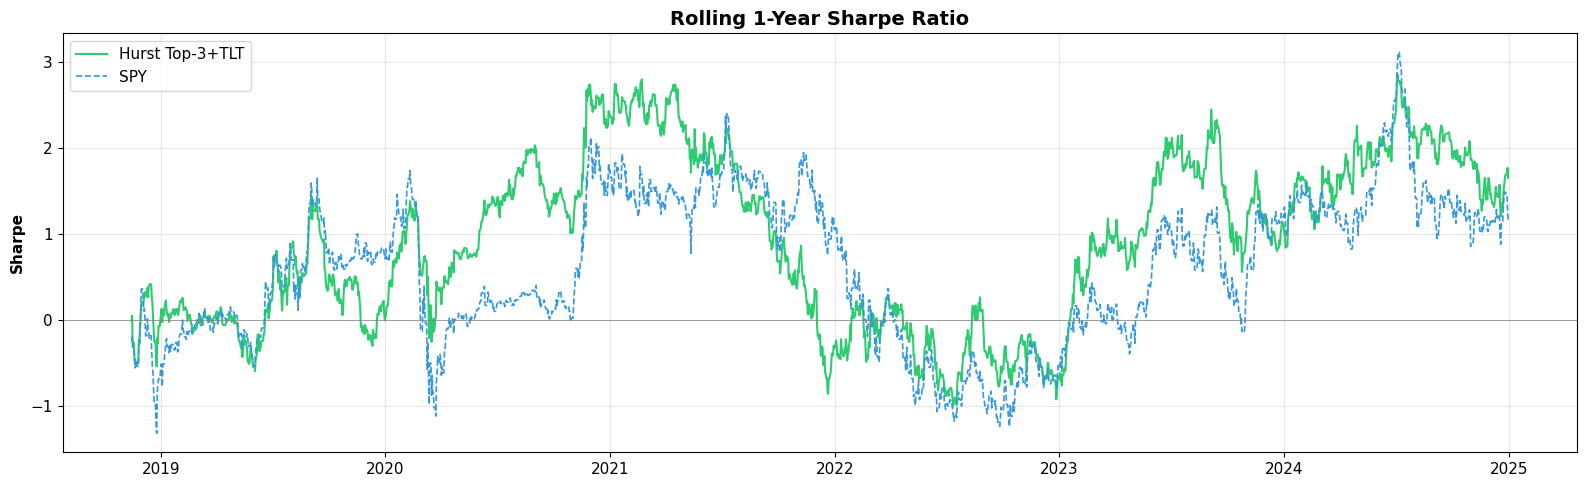

In [17]:
# ==============================================================
#  ROLLING 1-YEAR SHARPE RATIO
# ==============================================================

rfd   = (1.04) ** (1/252) - 1
rs_s  = ((port_ret.rolling(252).mean() - rfd)
         / port_ret.rolling(252).std() * np.sqrt(252))
rs_spy = ((spy_ret.rolling(252).mean() - rfd)
          / spy_ret.rolling(252).std() * np.sqrt(252))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(rs_s.index,   rs_s,   color='#2ecc71', lw=1.5,
        label=f'Hurst Top-{TOP_N}+TLT')
ax.plot(rs_spy.index, rs_spy, color='#3498db', lw=1.2,
        ls='--', label='SPY')
ax.axhline(0, color='gray', lw=0.5)
ax.set_title('Rolling 1-Year Sharpe Ratio', fontsize=14)
ax.set_ylabel('Sharpe')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Rebalance Log

In [18]:
# ==============================================================
#  REBALANCE LOG — LAST 20
# ==============================================================

print(f'Last 20 of {len(rebal_log)} rebalances:\n')
print(f'{"Date":>12} | {"Risk-On":>8} | {"TLT Wt":>7} | Selected Assets (Hurst)')
print('=' * 75)

for r in rebal_log[-20:]:
    d = r['date'].strftime('%Y-%m-%d')
    a = ', '.join(f"{t}({r['hurst_values'][t]:.3f})"
                  for t in r['selected'])
    if not a:
        a = '(none — 100% TLT)'
    print(f'{d:>12} | {r["n_selected"]:>8} | '
          f'{r["tlt_weight"]:>7.1%} | {a}')

Last 20 of 250 rebalances:

        Date |  Risk-On |  TLT Wt | Selected Assets (Hurst)
  2024-06-24 |        3 |    0.0% | BTC-USD(0.640), AMZN(0.611), TSLA(0.604)
  2024-07-04 |        3 |    0.0% | AMZN(0.720), QQQ(0.671), SPY(0.670)
  2024-07-14 |        3 |    0.0% | QQQ(0.645), SPY(0.610), BTC-USD(0.588)
  2024-07-24 |        3 |    0.0% | QQQ(0.725), SPY(0.698), AAPL(0.671)
  2024-08-03 |        3 |    0.0% | QQQ(0.701), AAPL(0.688), XLE(0.672)
  2024-08-13 |        3 |    0.0% | SPY(0.677), BTC-USD(0.663), QQQ(0.660)
  2024-08-23 |        3 |    0.0% | XLE(0.704), QQQ(0.661), NVDA(0.658)
  2024-09-02 |        3 |    0.0% | AAPL(0.741), AMZN(0.732), QQQ(0.722)
  2024-09-12 |        3 |    0.0% | BTC-USD(0.685), GLD(0.659), SPY(0.627)
  2024-09-22 |        3 |    0.0% | BTC-USD(0.727), SPY(0.682), QQQ(0.674)
  2024-10-02 |        3 |    0.0% | SPY(0.739), QQQ(0.713), XLE(0.708)
  2024-10-12 |        3 |    0.0% | SPY(0.726), QQQ(0.698), NVDA(0.689)
  2024-10-22 |        3 |    0.

---
## 7. Key Takeaways

### Lookahead Bias Prevention
This backtest is **lookahead-free**:
- Hurst at day t is computed from returns [t−63, t−1] — all known at close of t−1
- Signal is shifted by 1 day (`hurst_df = hurst_raw.shift(1)`)
- On rebalance day t, the backtest sees Hurst from day t−1
- Weights are applied to day t's return (close t−1 → close t)

### TLT Risk-Off Mechanism
- Acts as **flight-to-quality** during uncertain regimes (H ≈ 0.5)
- Bonds often rally during equity drawdowns → natural hedging
- Partial TLT allocation (1/3, 2/3) allows gradual risk scaling

### Potential Improvements

| Enhancement | Description |
|-------------|-------------|
| Momentum overlay | Combine Hurst with trailing returns for timing |
| Inverse-vol weighting | Weight by inverse volatility instead of equal |
| Walk-forward H threshold | Optimize min_hurst dynamically |
| Transaction costs | Add slippage + commission modeling |
| Multi-window Hurst | Average H across 21d, 63d, 126d windows |
| Long/short variant | Short bottom 3 (most anti-persistent) |
| GARCH vol filter | Reduce exposure during high volatility regimes |
| HMM regime detection | Macro regime filter before asset selection |